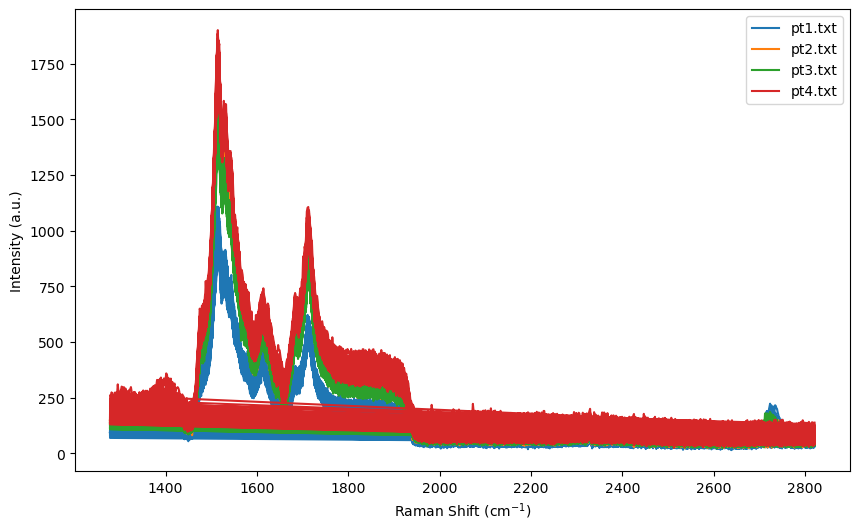

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import glob

file_list = sorted(glob.glob("pt*.txt"))

plt.figure(figsize=(10, 6))

for file in file_list:
    data_array = np.loadtxt(file, usecols=(2, 3), delimiter='\t', unpack=True, skiprows=1)
    x, y = data_array
    plt.plot(x, y, linestyle='-', label=file)

plt.xlabel('Raman Shift (cm$^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.legend()
plt.show()


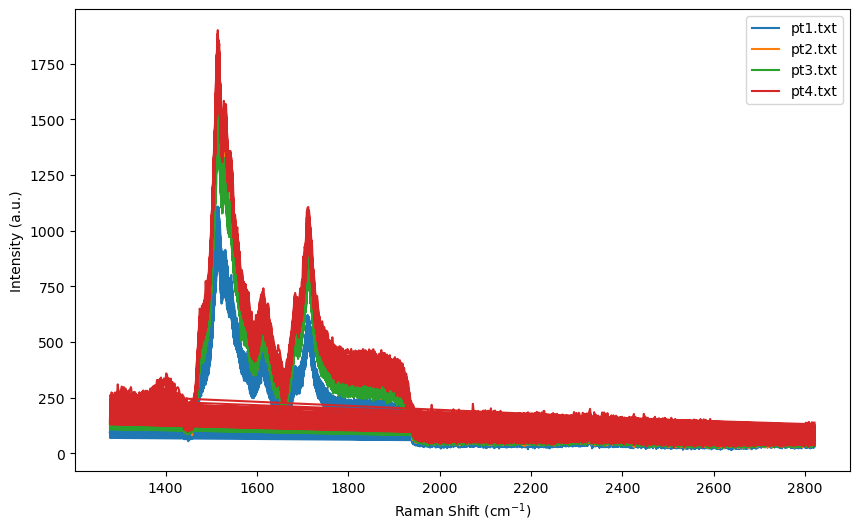

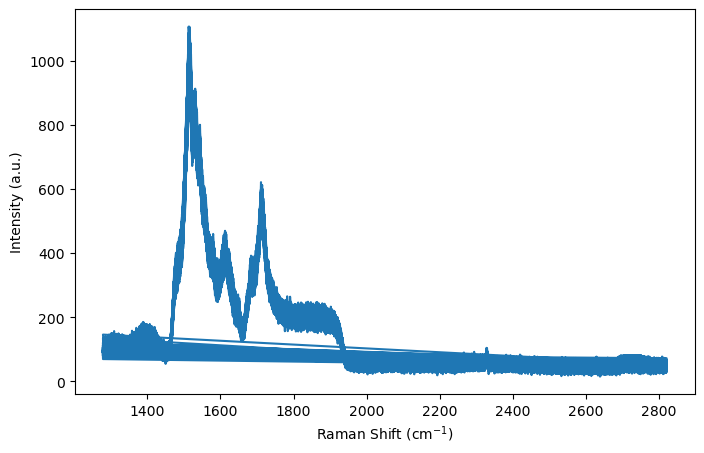

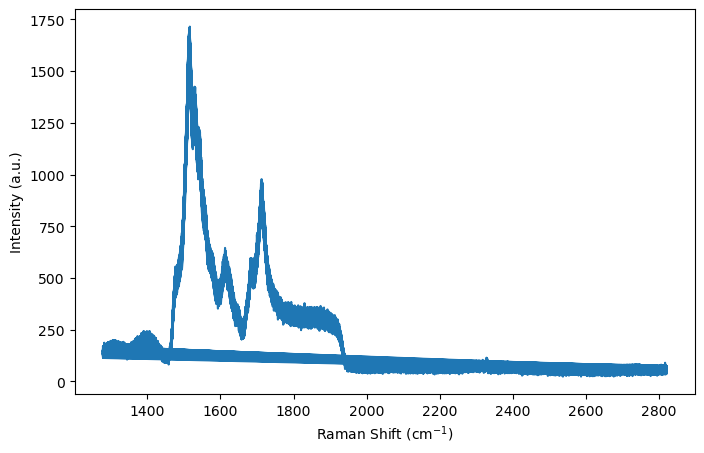

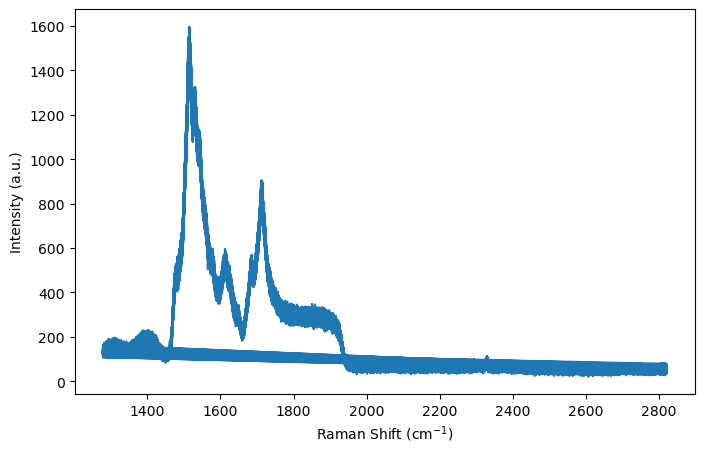

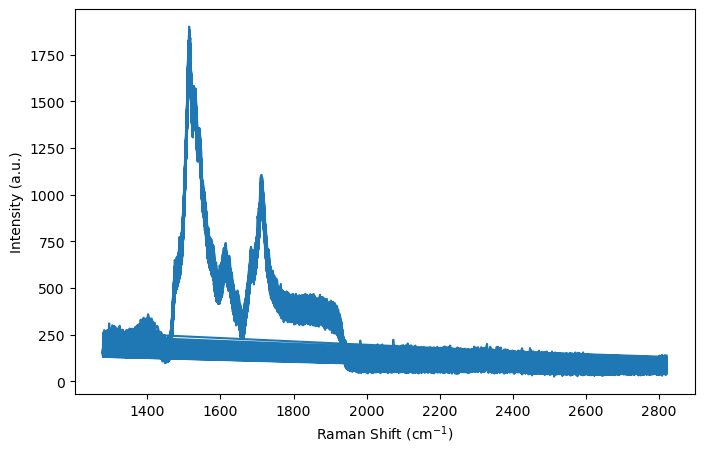

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import glob

file_list = sorted(glob.glob("pt*.txt"))
filtered_spectra = []

plt.figure(figsize=(10, 6))

for file in file_list:
    data_array = np.loadtxt(file, usecols=(2, 3), delimiter='\t', unpack=True, skiprows=1)
    x, y = data_array
    
    # mask 1
    mask = y <= 8500
    x_filtered = x[mask]
    y_filtered = y[mask]
    
   
    
    # mask 2d peak
    mask_range = (x_filtered >= 2600) & (x_filtered <= 2800) & (y_filtered > 80)
    x_final = x_filtered[~mask_range]
    y_final = y_filtered[~mask_range]
    
    
    
    filtered_spectra.append((x_final, y_final))
    plt.plot(x_final, y_final, linestyle='-', label=file)

plt.xlabel('Raman Shift (cm$^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.legend()
plt.show()


with open("filtered_spectra.txt", "w") as f:
    for x, y in filtered_spectra:
        for xi, yi in zip(x, y):
            f.write(f"{xi}\t{yi}\n")
        f.write("\n") 


for x_final, y_final in filtered_spectra:
    plt.figure(figsize=(8, 5))
    plt.plot(x_final, y_final, linestyle='-')
    plt.xlabel('Raman Shift (cm$^{-1}$)')
    plt.ylabel('Intensity (a.u.)')
    plt.show()
